# Исследования в области диаризации звуковых сигналов

In [2]:
import os
from pathlib import PosixPath
import IPython
import librosa.display
import matplotlib.pyplot as plt


## Общая информация о файле

In [11]:
base_dir = PosixPath(os.path.dirname(os.getcwd()))
data_dir = base_dir / 'data'
audio = data_dir / 'a8d49826-4b3b-4cc0-a0fd-efa403bf626f.mp3'

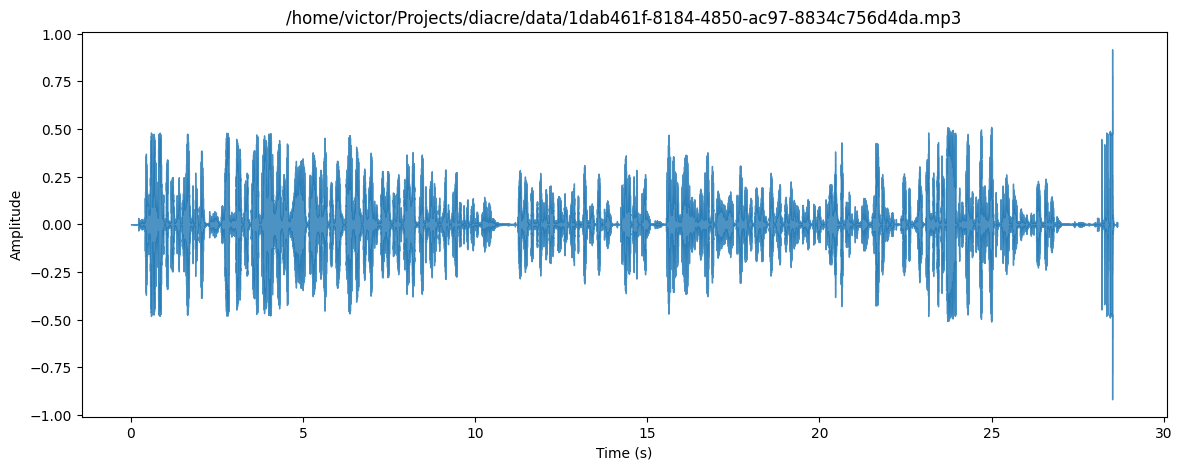

In [4]:
def plot_audio(file_path: PosixPath) -> None:
    plt.figure(figsize=(14, 5))
    y, sr = librosa.load(file_path, sr=None)
    librosa.display.waveshow(y, sr=sr, alpha=0.8)
    plt.title(file_path)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.show()

IPython.display.display(IPython.display.Audio(audio))
plot_audio(audio)

In [12]:
from pydub import AudioSegment
from pydantic import BaseModel

class SoundInfoSchema(BaseModel):
    channels: int
    """Количество каналов."""
    converter: str
    """Конвертер."""
    frame_rate: int
    """kHz, частота дискретизации."""
    frame_width: int
    sample_width: int

def sound_info(segment: AudioSegment) -> SoundInfoSchema:
    return SoundInfoSchema(
        channels=segment.channels,
        converter=segment.converter,
        frame_rate=segment.frame_rate,
        frame_width=segment.frame_width,
        sample_width=segment.sample_width,
    )

def sound_info_from_file(file_path: PosixPath) -> SoundInfoSchema:
    segment: AudioSegment = AudioSegment.from_file(file_path)
    return sound_info(segment)

info = sound_info_from_file(audio)
info

SoundInfoSchema(channels=1, converter='ffmpeg', frame_rate=8000, frame_width=2, sample_width=2)

## Сегментация

In [13]:
from pyannote.audio import Model

def make_segmentation():
    return Model.from_pretrained(base_dir / 'models' / 'pytorch_segmentation_model.bin')

segmentation = make_segmentation()


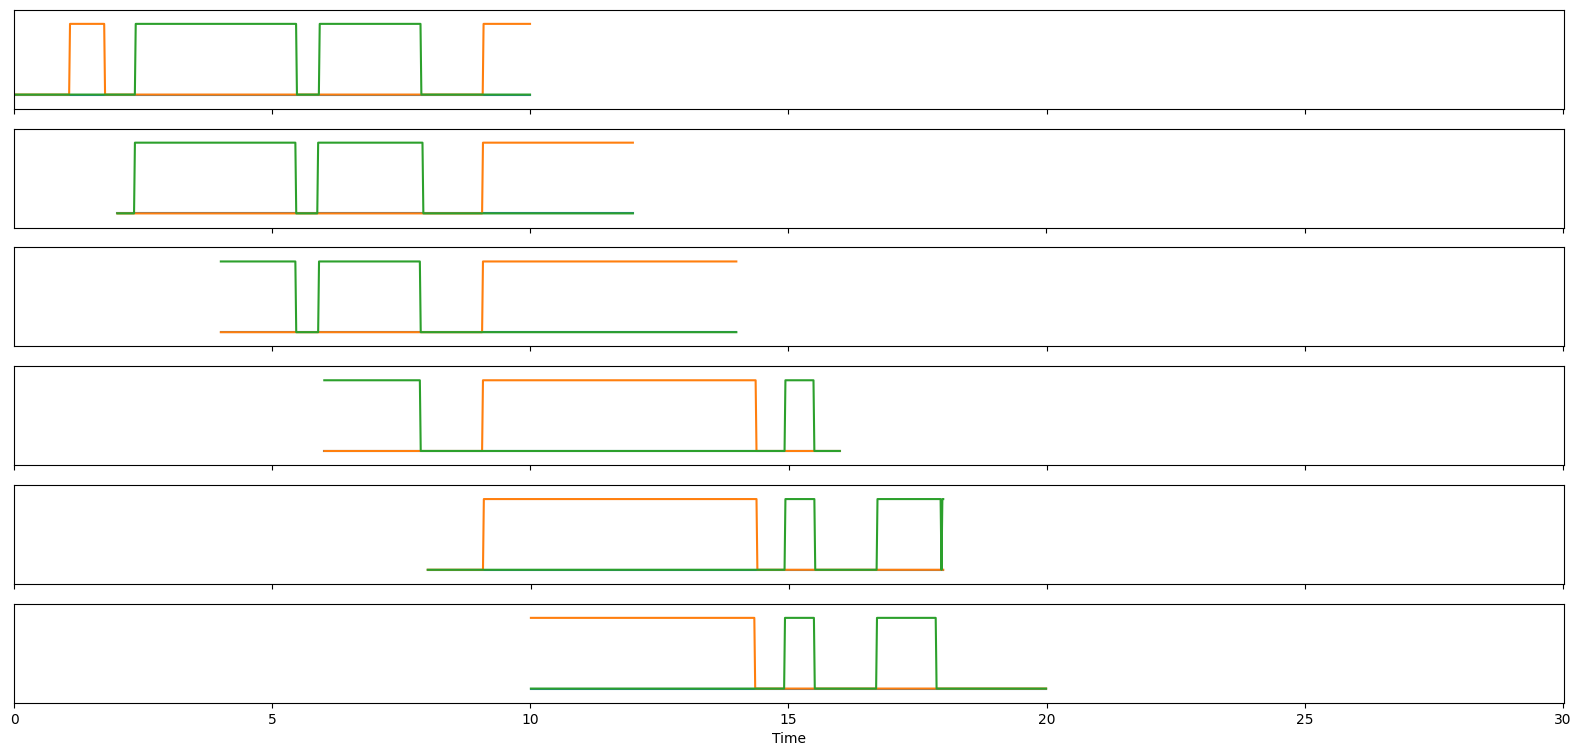

In [14]:
from pyannote.audio import Inference
from pyannote.core.feature import SlidingWindowFeature

inference = Inference(model=segmentation, step=2)
output: SlidingWindowFeature = inference(audio)
output

## Перебивание

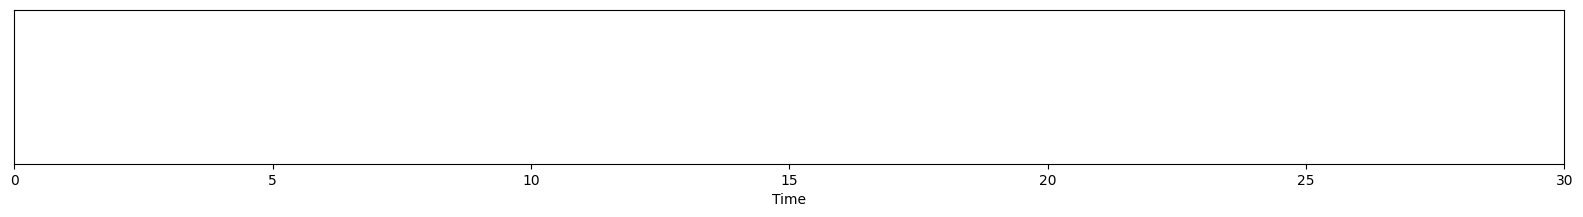

In [15]:
from pydantic import BaseModel
from pyannote.audio.pipelines import OverlappedSpeechDetection
pipeline = OverlappedSpeechDetection(segmentation=segmentation)

class OverlappedParamsSchema(BaseModel):
    """Onset/offset detection thresholds."""
    min_duration_on: float = .0
    """Remove speech regions shorter than that many seconds."""
    min_duration_off: float = .0

pipeline.instantiate(OverlappedParamsSchema().model_dump())
osd = pipeline(audio)
osd

## Обнаружение голосовой активности

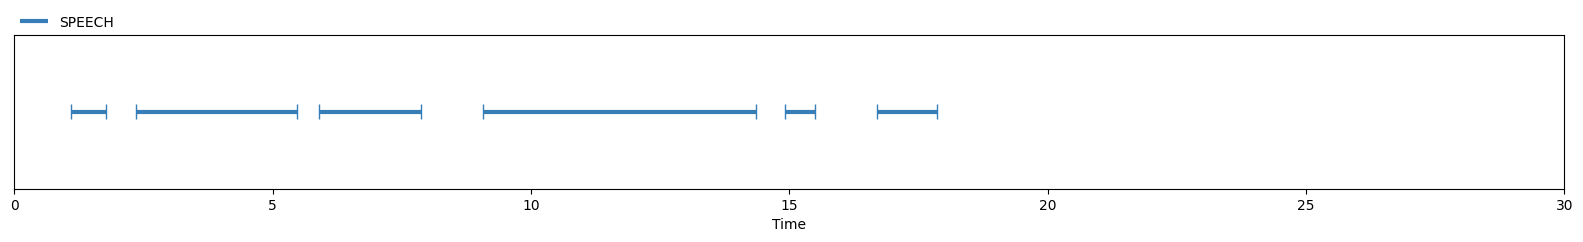

In [16]:
from pyannote.audio.pipelines import VoiceActivityDetection
from pyannote.core.annotation import Annotation
pipeline = VoiceActivityDetection(segmentation=segmentation)

pipeline = pipeline.instantiate(OverlappedParamsSchema().model_dump())
vad: Annotation = pipeline(audio)
vad

## Диаризация аудиозаписи

In [17]:
from pydantic import BaseModel, Field
from pyannote.audio.pipelines import SpeakerDiarization
from pyannote.audio.pipelines.clustering import AgglomerativeClustering
from pyannote.audio.models.embedding import WeSpeakerResNet34


class WeSpeakerResNetParamsSchema(BaseModel):
    sample_rate: int = 16000
    num_channels: int = 1
    num_mel_bins: int = 80
    frame_length: int = 25
    frame_shift: int = 10
    dither: float = .0
    window_type: str = 'hamming'
    use_energy: bool = False

class SegmentationParamsSchema(BaseModel):
    min_duration_off: float = .0

class AgglomerativeClusteringParamsSchema(BaseModel):
    method: str = 'centroid'
    threshold: float = 0.7045654963945799
    min_cluster_size: int = 12

class SpeakerDiarizationParamsSchema(BaseModel):
    segmentation: SegmentationParamsSchema = Field(default_factory=SegmentationParamsSchema)
    clustering: AgglomerativeClusteringParamsSchema = Field(default_factory=AgglomerativeClusteringParamsSchema)

def make_embedding(audio_info: SoundInfoSchema) -> WeSpeakerResNet34:
    embedding = WeSpeakerResNet34.from_pretrained(
        base_dir / 'models' / 'pytorch_speaker_model.bin',
        **WeSpeakerResNetParamsSchema(
            sample_rate=audio_info.frame_rate,
            num_channels=audio_info.channels,
        ).model_dump()
    )
    
    return embedding


pipeline = SpeakerDiarization(
    segmentation=make_segmentation(),
    embedding=make_embedding(info)
)
pipeline.instantiate(SpeakerDiarizationParamsSchema().model_dump())
pipeline

/home/victor/Projects/diacre/.venv/lib/python3.9/site-packages/torchaudio/_backend/soundfile_backend.py:71: UserWarning: The MPEG_LAYER_III subtype is unknown to TorchAudio. As a result, the bits_per_sample attribute will be set to 0. If you are seeing this warning, please report by opening an issue on github (after checking for existing/closed ones). You may otherwise ignore this warning.
  warnings.warn(
/home/victor/Projects/diacre/.venv/lib/python3.9/site-packages/torchaudio/_backend/soundfile_backend.py:71: UserWarning: The MPEG_LAYER_III subtype is unknown to TorchAudio. As a result, the bits_per_sample attribute will be set to 0. If you are seeing this warning, please report by opening an issue on github (after checking for existing/closed ones). You may otherwise ignore this warning.
  warnings.warn(
/home/victor/Projects/diacre/.venv/lib/python3.9/site-packages/torchaudio/_backend/soundfile_backend.py:71: UserWarning: The MPEG_LAYER_III subtype is unknown to TorchAudio. As a r

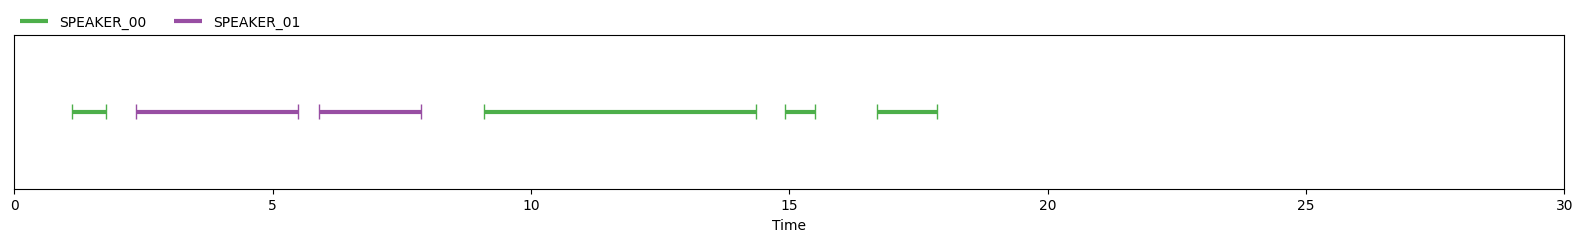

In [18]:
from pyannote.core.annotation import Annotation
diarization: Annotation = pipeline(audio, num_speakers=2)
diarization

## Конструирование стерео аудио файла

In [19]:
from pyannote.core.annotation import Annotation
from pydub import AudioSegment

def make_stereo(diarization: Annotation, audio_file: PosixPath) -> tuple[list[str], AudioSegment]:
    """На основе диаризации конструируем файл."""
    segment = AudioSegment.from_file(audio_file)
    audio_info = sound_info(segment)

    mono_audios: dict[str, AudioSegment] = {}

    diario = list(diarization.itersegments())
    speakers = [diarization.get_labels(seg).pop() for seg in diario]
    
    for index_segment, (seg, current_speaker,) in enumerate(zip(diario, speakers)):
        if current_speaker not in mono_audios:
            mono_audios[current_speaker] = AudioSegment.silent(seg.start * 1000, frame_rate=audio_info.frame_rate)
        mono_audios[current_speaker] += segment[seg.start * 1000:seg.end * 1000]
        
        if index_segment != 0 and current_speaker == speakers[index_segment - 1]:
            mono_audios[current_speaker] += AudioSegment.silent((seg.start - diario[index_segment - 1].end) * 1000, frame_rate=audio_info.frame_rate)

        for speaker in mono_audios:
            if speaker != current_speaker:
                # Если не текущий спикер, заполняем пустотой
                mono_audios[speaker] += AudioSegment.silent((seg.duration + seg.start - diario[index_segment - 1].end) * 1000, frame_rate=audio_info.frame_rate)
    
    frame_count: dict[str, float] = {speaker: mono_audio.frame_count() for speaker, mono_audio in mono_audios.items()}
    speaker_frame_count, max_frame_count = max(frame_count.items(), key=lambda x: x[1])
    
    for speaker in mono_audios:
        if speaker == speaker_frame_count:
            continue
        remaind = ((max_frame_count - frame_count[speaker]) / audio_info.frame_rate) * 1000
        mono_audios[speaker] += AudioSegment.silent(remaind, frame_rate=audio_info.frame_rate)

    result_segment = AudioSegment.from_mono_audiosegments(*mono_audios.values())
    return list(mono_audios.keys()), result_segment

speakers, result_audio_segment = make_stereo(diarization, audio)


In [20]:
result_audio_segment.export('result.mp3', format='mp3')
IPython.display.display(IPython.display.Audio('result.mp3'))